# 06 · Is spend *causing* sales? — causal MMM (pymc-marketing)

> **Runs in the `legacy` environment (pymc<6): `make env-legacy`, kernel `cmp-legacy`.**

**The business decision.** Brand search converts like crazy — should we pour budget into it? Be careful:
brand search mostly **catches** demand that upper-funnel channels (TV) and seasonality already created, so
crediting it for those conversions and shifting budget its way would be a mistake.

### The concepts

- **MMM (Marketing Mix Model)** — a regression of sales on each channel's spend over time (usually weekly),
  used to attribute sales to channels and set budgets. It's the "top-down" alternative to click-tracking.
- **Adstock (carry-over)** — advertising doesn't only work the week it runs; its effect *decays over
  subsequent weeks*. Adstock transforms raw spend into an "effective" exposure that carries over.
- **Saturation (diminishing returns)** — the 10th €1,000 into a channel buys less lift than the 1st. A
  saturation curve bends over as spend rises; its *slope* is the **marginal** return that should drive the
  next euro of budget.
- **Last-click attribution** — crediting the conversion to the final touch (often brand search). It
  systematically **over-credits** demand-capture channels, which is the error a causal MMM aims to fix.
- **Incremental vs mediated** — the *incremental* contribution of a channel is what it *caused*; a channel
  can show a big correlation with sales while causing very little (it was downstream of the real driver).

### The arc of this notebook — a cautionary tale with a resolution

A plain MMM regresses sales on all channels and is fooled by a **confounder** like seasonality (it lifts
sales *and* drives brand-search spend). The textbook fix is a **causal MMM**: hand it a **DAG** and let the
backdoor logic (nb 05) control for the confounder. This notebook shows that fix is **necessary but not
sufficient**, in three acts:

1. **The confounding correction works — in a linear model.** A naive OLS attribution that omits seasonality
   massively over-credits brand_search; adding seasonality as a control collapses that credit toward the
   small truth. That's the cleanest way to *see* the confounding, and it's robust.
2. **The out-of-the-box causal MMM still inverts the ranking.** Fit with library-default priors, the MMM's
   *flexible saturation curve* for brand_search **re-absorbs** the seasonal demand the linear control was
   meant to remove — so it credits brand_search *more* than TV, the opposite of the truth. A DAG plus a
   linear control does **not** de-confound a channel whose spend is collinear with the confounder.
3. **Experiment-calibrated priors recover it.** Feed in what a small **geo experiment** teaches — that
   brand_search's incremental effect is small — as an informative prior on its saturation, and the MMM
   ranks the channels correctly again. **This is why MMMs must be calibrated with experiments** (Anchor B,
   nb 07): observational data alone cannot pin the decomposition.

> **On real data.** Swap in your **own weekly spend-by-channel + sales** table plus known confounders
> (seasonality, price, distribution). Public example: the datasets shipped with Meta's *Robyn* or
> `pymc-marketing`'s own tutorials. Always pair an MMM with occasional geo experiments to anchor the levels.

It follows the repo's fixed **7-step contract**: question → simulate → identify → estimate → validate → decide in € → caveats.

In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from pymc_marketing.mmm import MMM, GeometricAdstock, MichaelisMentenSaturation
from pymc_marketing.prior import Prior
from cmp import dgp, plots, estimators as est
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
DRAWS = dict(draws=250, tune=300, chains=2) if FAST else dict(draws=1200, tune=2000, chains=4)
# Even with the season->brand_search collinearity kept moderate in the DGP, the MMM's saturation
# geometry needs deeper trees + high target_accept + long tuning to converge cleanly (r-hat ~1.01).
NUTS = dict(target_accept=0.9) if FAST else dict(target_accept=0.99, max_treedepth=13)
SEED = 21
# Step-5 prior-sensitivity sweep refits: deliberately RANKING-GRADE (short chains, enough for
# stable posterior means and a stable ranking probability, not interval-grade diagnostics) so the
# sweep stays cheap in BOTH profiles — the FULL headline fits above are the only long chains here.
SWEEP_DRAWS = dict(draws=150, tune=200, chains=2) if FAST else dict(draws=250, tune=300, chains=2)

## 2 · Simulate a ground truth

Weekly sales from a faithful **adstock + Michaelis-Menten saturation** process. **TV** is a big
genuine driver. **seasonality** is a **confounder** — it lifts sales directly *and* drives
brand-search spend. **brand_search** has only a *small* real effect, but its spend rides the
seasonal wave (corr ≈ 0.78), so a naive attribution ignoring seasonality massively over-credits it.
Honest answer: TV highly incremental, brand_search only slightly.

**The data-generating model** — exactly what `dgp.mmm_weekly` implements (defaults & seed in
`src/cmp/dgp.py`). Weeks $t = 0,\dots,155$; seasonality $s_t = \sin(2\pi t/52)$:

$$
\begin{aligned}
x^{\text{tv}}_t &= \max\{1,\; 40 + 8\,s_t + \varepsilon^{\text{tv}}_t\},
  \quad \varepsilon^{\text{tv}}_t \sim \mathcal N(0, 8^{2});
  \qquad
x^{\text{bs}}_t = \max\{1,\; 25 + 11\,s_t + \varepsilon^{\text{bs}}_t\},
  \quad \varepsilon^{\text{bs}}_t \sim \mathcal N(0, 7^{2})\\[2pt]
a_t(x;\lambda) &= x_t + \lambda\, a_{t-1}(x;\lambda) \qquad\text{(geometric adstock / carry-over)}\\[2pt]
f(a;\alpha,\kappa) &= \frac{\alpha\, a}{\kappa + a} \qquad\text{(Michaelis–Menten saturation)}\\[2pt]
\text{sales}_t &= 100
  \;+\; \underbrace{f\big(a_t(x^{\text{tv}};\,0.4);\; 60,\, 50\big)}_{\text{TV: big, real}}
  \;+\; \underbrace{f\big(a_t(x^{\text{bs}};\,0.2);\; 8,\, 40\big)}_{\text{brand search: small, real}}
  \;+\; \underbrace{35\, s_t}_{\text{season} \to \text{sales}}
  \;+\; \varepsilon_t, \qquad \varepsilon_t \sim \mathcal N(0,\, 4^{2}).
\end{aligned}
$$

The confounding is the **two appearances of $s_t$**: it drives brand-search spend (the $11\,s_t$
term — people search the brand more in peak season; corr ≈ 0.78) *and* sales directly (the
$35\,s_t$ term). An MMM that omits seasonality hands much of that $35\,s_t$ to brand search. Note
the generator uses the MMM's own functional form (adstock → saturation), so the model is
well-specified — any remaining failure is about *identification*, not fit. **Identification** is whether the data can, even in principle, pin down the answer uniquely: a model can fit the sales series perfectly and still leave the *split* of credit between two channels undetermined — that gap between 'fits' and 'is identified' is the whole subject of this notebook.


In [2]:
df, true_contrib = dgp.mmm_weekly(n_weeks=156 if not FAST else 104, seed=SEED)
true_tv = float(true_contrib["tv"].sum()); true_bs = float(true_contrib["brand_search"].sum())
print(f"TRUE incremental sales — TV {true_tv:,.0f}   brand_search {true_bs:,.0f} (small)")
df.head()

TRUE incremental sales — TV 5,263   brand_search 518 (small)


,date_week,tv,brand_search,seasonality,sales
0,2023-01-02,42.870187,35.579322,0.000000,134.900978
1,2023-01-09,53.049712,17.732754,0.120537,137.863335
2,2023-01-16,27.623875,23.486826,0.239316,142.263680
3,2023-01-23,56.329747,34.885672,0.354605,159.788875
4,2023-01-30,43.339248,33.736743,0.464723,152.485792


### First — look at the data: the confounding, made visible

Two pictures to hold in your head for the rest of the notebook, drawn **before any model sees the
data**:

1. **Spend rides the seasonal wave.** brand_search's spend is *built* from the same seasonal index
   that lifts sales, so it tracks the dashed wave far more tightly than TV does (both correlations
   are printed in the legend). Whatever the season does to sales will look, to a model that ignores
   the season, like brand_search doing it.
2. **Most of what brand_search appears to move is the season.** The right panel plots the *planted*
   weekly components of sales: TV's contribution is large, the ±35 seasonal swing is larger still —
   and brand_search's true contribution is the near-flat line hugging the bottom. An attribution
   method must hand the wave back to the season; everything that follows is about whether it does.

corr(spend, seasonality): brand_search 0.78 vs tv 0.63 — the confounder is entangled
with brand_search; true weekly contributions: TV ≈ €34, brand_search ≈ €3, season swing ±€35.


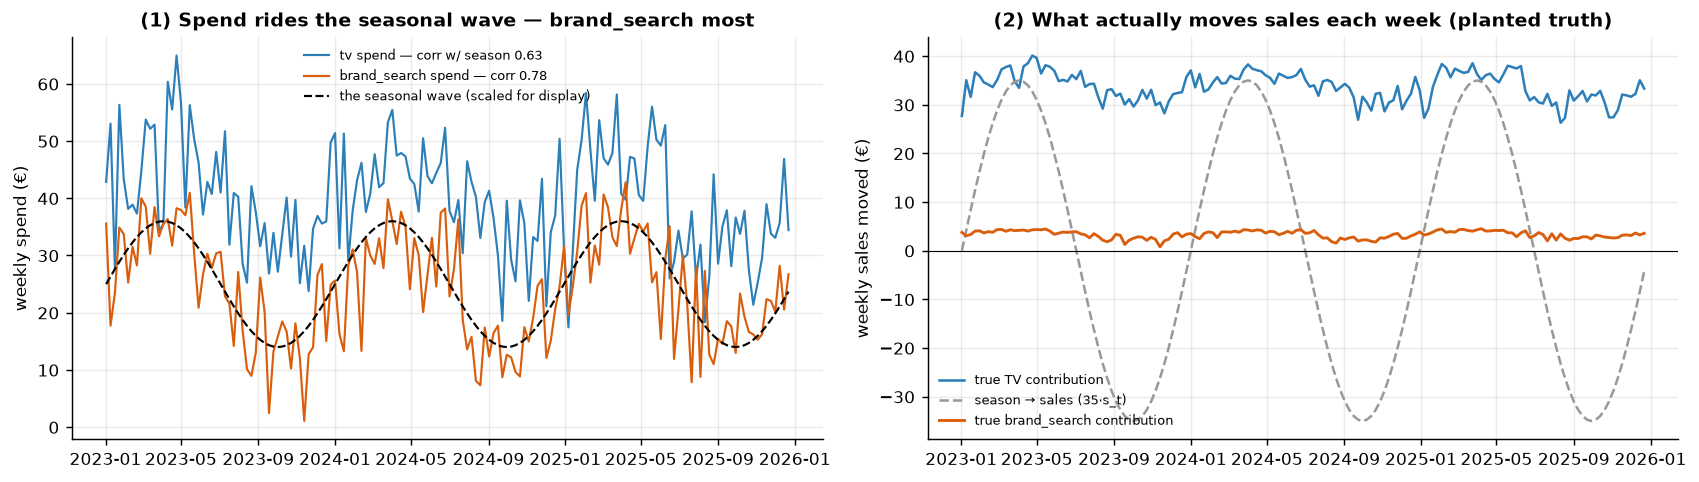

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13.2, 3.8))
c_tv = df["tv"].corr(df["seasonality"]); c_bs = df["brand_search"].corr(df["seasonality"])
ax[0].plot(df["date_week"], df["tv"], color=plots.BLUE, lw=1.2, label=f"tv spend — corr w/ season {c_tv:.2f}")
ax[0].plot(df["date_week"], df["brand_search"], color=plots.ORANGE, lw=1.2,
           label=f"brand_search spend — corr {c_bs:.2f}")
ax[0].plot(df["date_week"], 25 + 11 * df["seasonality"], color="k", ls="--", lw=1.2,
           label="the seasonal wave (scaled for display)")
ax[0].set_ylabel("weekly spend (€)"); ax[0].legend(frameon=False, fontsize=7)
ax[0].set_title("(1) Spend rides the seasonal wave — brand_search most")
ax[1].plot(df["date_week"], true_contrib["tv"], color=plots.BLUE, lw=1.4, label="true TV contribution")
ax[1].plot(df["date_week"], 35 * df["seasonality"], color=plots.GREY, lw=1.4, ls="--",
           label="season → sales (35·s_t)")
ax[1].plot(df["date_week"], true_contrib["brand_search"], color=plots.ORANGE, lw=1.6,
           label="true brand_search contribution")
ax[1].axhline(0, color="k", lw=0.6)
ax[1].set_ylabel("weekly sales moved (€)"); ax[1].legend(frameon=False, fontsize=7)
ax[1].set_title("(2) What actually moves sales each week (planted truth)")
fig.tight_layout()
print(f"corr(spend, seasonality): brand_search {c_bs:.2f} vs tv {c_tv:.2f} — the confounder is entangled")
print(f"with brand_search; true weekly contributions: TV ≈ €{np.mean(true_contrib['tv']):,.0f}, "
      f"brand_search ≈ €{np.mean(true_contrib['brand_search']):,.0f}, season swing ±€35.")

### The two transforms, before we use them in anger

The MMM's channel response is built from the two primitives the generator above already used —
worth ten seconds of intuition each before a sampler spends minutes on them. **Adstock** answers
*"how long does an ad echo?"*: with geometric decay $\lambda$, a euro of spend still exerts
$\lambda^{\ell}$ of its initial push $\ell$ weeks later, so $\lambda = 0.2$ is a one-week echo
while $\lambda = 0.8$ still echoes seven weeks out. **Saturation** answers *"what is the next euro
worth?"*: the Michaelis–Menten curve $f(a) = \alpha a/(\kappa + a)$ climbs toward a **ceiling**
$\alpha$ — the most the channel could ever add per week — and passes half of it exactly at
$a = \kappa$, the **half-saturation** point. Keep the right panel in mind for Step 4b: the
experiment-calibrated prior acts on the *ceiling* $\alpha$, the parameter that says how much a
channel could possibly deliver — precisely the number a lift test measures.

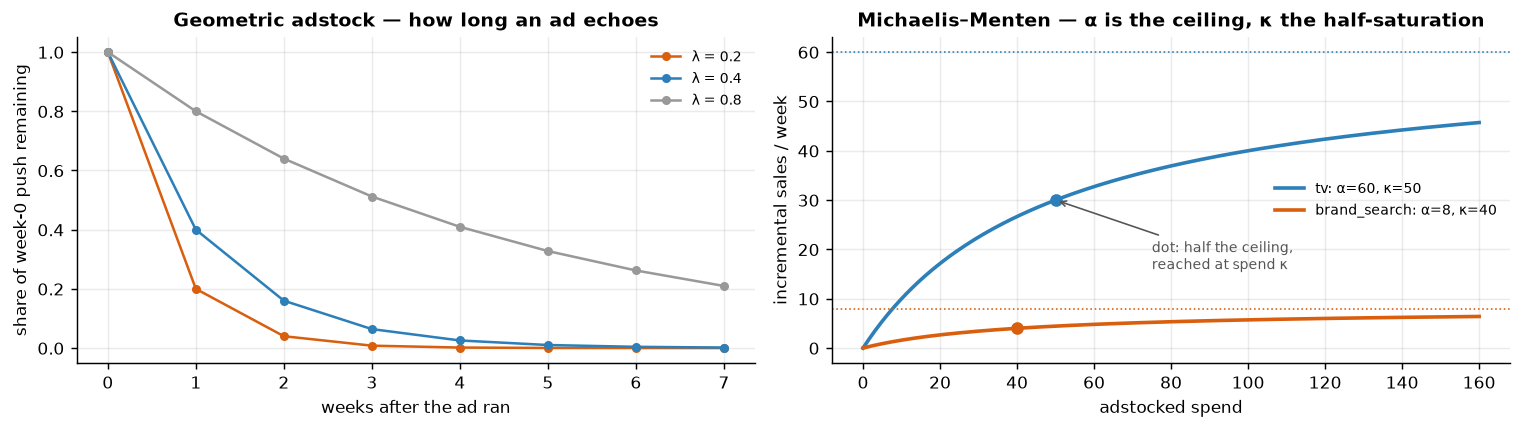

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11.8, 3.4))
ell = np.arange(8)
for lam, col in [(0.2, plots.ORANGE), (0.4, plots.BLUE), (0.8, plots.GREY)]:
    ax[0].plot(ell, lam ** ell, "o-", ms=4, lw=1.4, color=col, label=f"λ = {lam}")
ax[0].set_xlabel("weeks after the ad ran"); ax[0].set_ylabel("share of week-0 push remaining")
ax[0].set_title("Geometric adstock — how long an ad echoes"); ax[0].legend(frameon=False, fontsize=8)
a_grid = np.linspace(0, 160, 200)
for (al, ka), col, lab in [((60, 50), plots.BLUE, "tv: α=60, κ=50"),
                           ((8, 40), plots.ORANGE, "brand_search: α=8, κ=40")]:
    ax[1].plot(a_grid, al * a_grid / (ka + a_grid), color=col, lw=2, label=lab)
    ax[1].axhline(al, color=col, ls=":", lw=0.9)
    ax[1].plot([ka], [al / 2], "o", color=col, ms=6)
ax[1].annotate("dot: half the ceiling,\nreached at spend κ", xy=(50, 30), xytext=(75, 16),
               fontsize=7.5, color="#555555", arrowprops=dict(arrowstyle="->", color="#555555", lw=0.9))
ax[1].set_xlabel("adstocked spend"); ax[1].set_ylabel("incremental sales / week")
ax[1].set_title("Michaelis–Menten — α is the ceiling, κ the half-saturation")
ax[1].legend(frameon=False, fontsize=8, loc="center right")
fig.tight_layout()

## 3 · Identify — the marketing DAG picks what to control for

DAG: `seasonality → {sales, brand_search}`, `tv → sales`, `brand_search → sales`. The backdoor
criterion says **seasonality is a confounder → control for it**; omitting it is exactly the
last-click mistake that over-credits brand search. (This DAG has a confounder but no **mediator** — a
variable sitting *on* the causal path from spend to sales, which you would deliberately *not* control for;
nb 05 covers that distinction.) The **estimand** — the precise quantity we want to estimate — for channel
$c$ is its **incremental contribution** — sum over weeks of
$\mathbb E[\text{sales}\mid do(\text{spend}_c=\text{observed})]-\mathbb E[\text{sales}\mid do(\text{spend}_c=0)]$,
holding the other channels at their observed spend (how much of sales would vanish if we switched channel $c$
off). Here $do(\cdot)$ denotes an **intervention** — setting spend by decree rather than merely observing it
(nb 05). **ROAS** (return on ad spend) = incremental contribution ÷ spend, each with a posterior — note this
is *revenue*, not profit, so at 1× you break even only on a 100% margin (we return to margins in Step 6).
Identification comes from the backdoor set $\{\text{seasonality}\}$; we hand the DAG to the MMM via `dag`,
`treatment_nodes`, `outcome_node`.

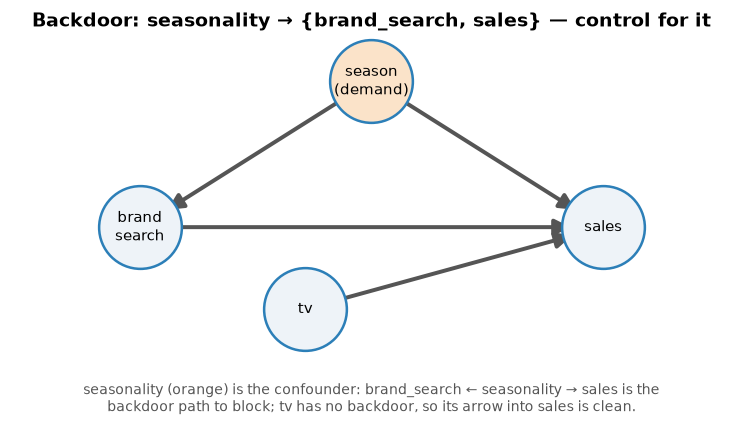

In [5]:
fig, ax = plt.subplots(figsize=(5.8, 3.4))
pos = {"season\n(demand)": (0.5, 1.0), "brand\nsearch": (0.08, 0.5), "tv": (0.38, 0.22), "sales": (0.92, 0.5)}
edges = [("season\n(demand)", "brand\nsearch"), ("season\n(demand)", "sales"),
         ("brand\nsearch", "sales"), ("tv", "sales")]
plots.draw_dag(ax, pos, edges, node_colors={"season\n(demand)": "#fbe3c9"},
               title="Backdoor: seasonality → {brand_search, sales} — control for it")
ax.text(0.5, -0.13, "seasonality (orange) is the confounder: brand_search ← seasonality → sales is the\n"
                    "backdoor path to block; tv has no backdoor, so its arrow into sales is clean.",
        ha="center", fontsize=7.5, color="#555555")
fig.tight_layout()

In [6]:
dag = '''digraph { seasonality -> sales; seasonality -> brand_search; tv -> sales; brand_search -> sales; }'''
X = df[["date_week","tv","brand_search","seasonality"]]; y = df["sales"]

def make_mmm(model_config=None):
    return MMM(date_column="date_week", channel_columns=["tv","brand_search"], control_columns=["seasonality"],
               adstock=GeometricAdstock(l_max=8), saturation=MichaelisMentenSaturation(),
               dag=dag, treatment_nodes=["tv","brand_search"], outcome_node="sales",
               model_config=model_config)

mmm_default = make_mmm()
print("Backdoor adjustment set the causal layer will use:",
      mmm_default.causal_graphical_model.adjustment_set if hasattr(mmm_default,"causal_graphical_model") else "n/a")

Backdoor adjustment set the causal layer will use: ['seasonality']


## 4 · Estimate — fit the causal MMM twice

We fit the **same DAG-aware MMM twice**, to make the lesson unmissable:

- **(a) default priors** — the honest, out-of-the-box causal MMM. Watch it *invert* the ranking.
- **(b) experiment-calibrated priors** — encode what a geo experiment teaches (brand_search's incremental
  effect is small) as an informative prior on its saturation ceiling, and watch the ranking snap back.

**The fitted model, in symbols.** Per channel $c \in \{\text{tv}, \text{brand\_search}\}$, spend is
adstocked over an 8-week window, saturated, and summed with the control:

$$
\text{sales}_t \sim \mathcal N\Big(\beta_0 + \textstyle\sum_c f_c\big(a_c(x^{c})_t\big)
  + \gamma\, s_t,\;\; \sigma^{2}\Big), \qquad
a_c(x)_t \propto \sum_{\ell=0}^{7} \lambda_c^{\ell}\, x_{t-\ell}, \qquad
f_c(a) = \frac{\alpha_c\, a}{\kappa_c + a},
$$

geometric adstock (`GeometricAdstock(l_max=8)`) and Michaelis–Menten saturation, with each
channel's decay $\lambda_c$, ceiling $\alpha_c$ and half-saturation $\kappa_c$ **estimated** from
the data. Fit (a) leaves their priors at library defaults; fit (b) replaces the prior on
brand-search's ceiling $\alpha_{\text{bs}}$ with the experiment-informed one. Note the functional
form matches step 2's generator exactly — this is the *well-specified best case*, which is what
makes the ranking inversion in (a) a lesson about identification rather than model misfit.
(pymc-marketing scales variables internally; the equations are written in original units for
readability.)

**The priors, made explicit.** "Library defaults" in fit (a) means, per channel $c$ (all on
**max-abs-scaled** spend and sales — pymc-marketing divides each channel's spend and the sales
series by its own maximum before fitting; Step 4b returns to why that matters):

$$
\begin{gathered}
\lambda_c \sim \mathrm{Beta}(1,\, 3), \qquad
\alpha_c \sim \mathrm{Gamma}(\mu = 2,\ \sigma = 1), \qquad
\kappa_c \sim \mathrm{HalfNormal}(1),\\[3pt]
\beta_0,\, \gamma \sim \mathcal N(0,\, 2), \qquad
\sigma_y \sim \mathrm{HalfNormal}(2).
\end{gathered}
$$

The one to stare at is the saturation **ceiling** $\alpha_c$, in scaled-sales units: a prior mean
of 2 says "this channel could plausibly add up to about *twice the all-time weekly sales peak*,
every week" — weakly-informative in the worst sense, generous exactly along the direction the data
cannot push back on. Fit (b) replaces only brand-search's copy of that one prior.

Convergence housekeeping: this is the hardest posterior geometry in the cookbook — the FULL
profile needs `target_accept = 0.99` and deeper trees to reach R-hat ≈ 1.01 (the diagnostics —
R-hat, ESS, divergences — are defined in notebook 01's “did the sampler converge?” box). Even then, expect fit (a) to log **a dozen-odd** divergences and fit (b) to sit exactly
at the 1.01 edge — and in FAST mode either fit's short chains can disagree outright
(R-hat ≫ 1.01). Read those complaints as **information, not nuisance**: the sampler is
struggling along the very season/brand-search ridge — a flat valley of near-equivalent answers — that breaks identification (we show it in
the flesh right after the fit). We quote fit (a) only for its — robustly wrong — ranking, never
for its intervals.

A caution that runs through both: **MMMs are miscalibrated in *absolute* terms** — with channel spend riding
seasonal demand, a short weekly series can't fully separate "channel drove sales" from "season drove both",
so fitted contributions run high. What we're after is the **ranking** and each channel's **ROI verdict**.

In [7]:
idata_def = mmm_default.fit(X, y, random_seed=SEED, progressbar=False, **NUTS, **DRAWS)
print(f"(a) default-prior MMM convergence: {est.convergence_report(idata_def)['summary']}")
cdef = mmm_default.compute_channel_contribution_original_scale().sum(dim="date")
tv_def = cdef.sel(channel="tv").values.ravel(); bs_def = cdef.sel(channel="brand_search").values.ravel()
print(f"(a) default contribution — TV {tv_def.mean():,.0f}   brand_search {bs_def.mean():,.0f}")
print(f"    true: TV {true_tv:,.0f}, brand_search {true_bs:,.0f}  ->  the MMM ranks brand_search ABOVE TV (inverted!).")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept, adstock_alpha, saturation_alpha, saturation_lam, gamma_control, y_sigma]


Sampling 4 chains for 2_000 tune and 1_200 draw iterations (8_000 + 4_800 draws total) took 1361 seconds.


There were 14 divergences after tuning. Increase `target_accept` or reparameterize.


Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

(a) default-prior MMM convergence: max r-hat 1.010 - min ESS 381 - divergences 14
(a) default contribution — TV 10,390   brand_search 36,007
    true: TV 5,263, brand_search 518  ->  the MMM ranks brand_search ABOVE TV (inverted!).


### Why the out-of-the-box MMM inverts the ranking

The default MMM credits brand_search *above* TV — backwards. The mechanism is worth seeing, because it's a
real trap:

- brand_search's spend is *built* to ride the seasonal demand wave (Step 2 constructs it from the same
  seasonal index that drives sales), and the fit lets its flexible saturation curve quietly **re-absorb the
  seasonal demand** the linear `seasonality` control was meant to remove.
- Because brand_search rides the seasonal wave more tightly than TV does, it wins that tug-of-war and books
  a huge contribution (tens of thousands vs a true ~500), while a large **negative baseline** offsets it —
  the classic broken **level decomposition** — how the model splits the *absolute* level of sales across baseline + channels — of a non-identified MMM.
- The DAG was right and the control was present; they still weren't enough. **A linear confounder-control
  does not de-confound a channel whose spend is **collinear** with (moves almost in lockstep with) the confounder and enters through a flexible
  functional form.** Observational data alone can't break the tie.

Those are three checkable claims — collinear spend, a posterior tug-of-war, a negative
baseline — so the next cell checks them, in the data and in fit (a)'s own posterior.

spend–confounder correlations (the tv row is the contrast):
                tv  brand_search  seasonality
tv            1.00          0.54         0.63
brand_search  0.54          1.00         0.78
seasonality   0.63          0.78         1.00

draw-level corr(α_bs, γ) = +0.01   ·   per-chain α_bs posterior means: [1.27 1.3  1.25 1.24]
truth in scaled units: α_bs ≈ 0.044, γ ≈ 0.191 — the green star, far from the mass.
intercept (original scale): mean €-160/week vs planted baseline €100/week  -> NEGATIVE: the level decomposition is broken.


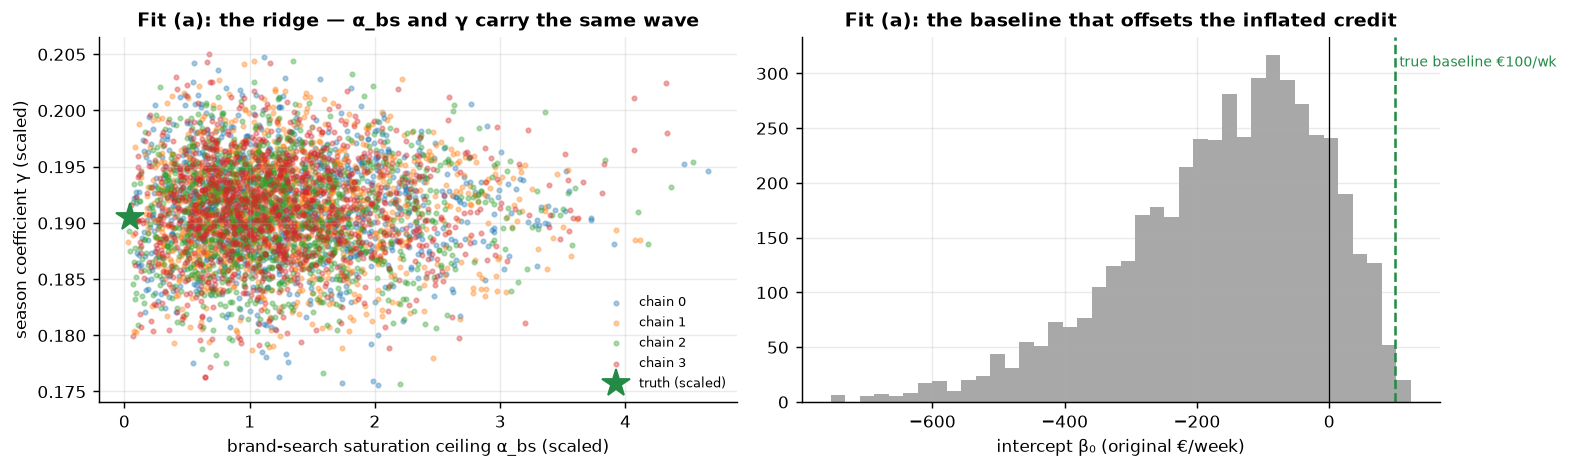

In [8]:
# Evidence for the three claims of the cell above — computed, not asserted.
# (i) the collinearity: spend vs the confounder
print("spend–confounder correlations (the tv row is the contrast):")
print(df[["tv", "brand_search", "seasonality"]].corr().round(2).to_string())

y_max = float(np.abs(y).max())        # pymc-marketing max-abs-scales the target; used to un-scale below
post_d = idata_def.posterior
a_bs_d = post_d["saturation_alpha"].sel(channel="brand_search")   # brand-search ceiling (scaled units)
gam_d = post_d["gamma_control"].isel(control=0)                   # seasonality coefficient (scaled units)

fig, ax = plt.subplots(1, 2, figsize=(12.2, 3.7))
# (ii) the posterior ridge: each dot is one draw of (ceiling, season coefficient), coloured by chain
for c in range(post_d.sizes["chain"]):
    ax[0].scatter(a_bs_d.isel(chain=c).values, gam_d.isel(chain=c).values, s=6, alpha=0.35,
                  label=f"chain {c}")
ax[0].plot([8 / y_max], [35 / y_max], "*", color=plots.GREEN, ms=16, label="truth (scaled)")
ax[0].set_xlabel("brand-search saturation ceiling α_bs (scaled)")
ax[0].set_ylabel("season coefficient γ (scaled)")
ax[0].set_title("Fit (a): the ridge — α_bs and γ carry the same wave")
ax[0].legend(frameon=False, fontsize=7)
# (iii) the baseline that pays for the stolen credit
ic_d = post_d["intercept"].values.ravel() * y_max
ax[1].hist(ic_d, bins=40, color=plots.GREY, alpha=0.85)
ax[1].axvline(100, color=plots.GREEN, ls="--", lw=1.4)
ax[1].text(100, ax[1].get_ylim()[1] * 0.92, " true baseline €100/wk", fontsize=8, color=plots.GREEN)
ax[1].axvline(0, color="k", lw=0.7)
ax[1].set_xlabel("intercept β₀ (original €/week)")
ax[1].set_title("Fit (a): the baseline that offsets the inflated credit")
fig.tight_layout()

rho = float(np.corrcoef(a_bs_d.values.ravel(), gam_d.values.ravel())[0, 1])
ch_means = a_bs_d.mean(dim="draw").values
print(f"\ndraw-level corr(α_bs, γ) = {rho:+.2f}   ·   per-chain α_bs posterior means: {np.round(ch_means, 2)}")
print(f"truth in scaled units: α_bs ≈ {8 / y_max:.3f}, γ ≈ {35 / y_max:.3f} — the green star, far from the mass.")
print(f"intercept (original scale): mean €{ic_d.mean():,.0f}/week vs planted baseline €100/week"
      + ("  -> NEGATIVE: the level decomposition is broken." if ic_d.mean() < 0
         else "  -> dragged far below the truth: the level decomposition is strained."))
if ch_means.max() / max(ch_means.min(), 1e-9) > 2:
    print("Note the per-chain means: the chains sit on DIFFERENT stretches of the ridge — each found its own\n"
          "split of the same wave and never reconciled. That is the R-hat warning above, drawn as a picture.")

**Read-out.** *Left*: every dot is a posterior draw of (brand-search ceiling $\alpha_{bs}$, season
coefficient $\gamma$). The truth (green star) has a tiny ceiling; the posterior instead spreads
along a **ridge** of near-equivalent decompositions — draws (and, at FAST settings, whole chains)
trade the seasonal wave back and forth between the two parameters, because the likelihood is
near-flat along that direction. *Right*: to pay for the inflated brand-search credit, the intercept
is dragged far below the planted €100/week — the classic broken level decomposition of a
non-identified MMM, exactly the "large negative baseline" claimed above. When two regressors carry
the same wave, the posterior does not pick one: it spreads over every split the data cannot
distinguish, and under the default priors the flexible saturation curve books the credit. **No
amount of extra sampling fixes this — only information from outside the dataset can.** Which is the
move of the next section.

### The fix — priors calibrated from a geo experiment

The standard remedy is exactly the discipline of Anchor B (the cookbook's 'calibrate MMMs with experiments' rule, nb 07): run a **small geo experiment** — which randomizes a channel's spend across matched groups of regions (some markets get the ads, some don't) and reads the sales gap as that channel's *true* incremental lift, uncontaminated by the seasonality the observational data can't net out (full treatment in nb 07) — to learn
that brand_search's *incremental* effect is small, and feed that back as an **informative prior on its
saturation ceiling** (`saturation_alpha`). TV, whose incremental role we haven't independently pinned down,
keeps a weakly-informative prior. This is not putting a thumb on the scale — it's using experimental
evidence exactly where observational data is silent.

**From experimental euros to a prior — the mapping, explicitly.** The geo test (nb 07) delivers an
estimate of brand-search's total incremental sales over its test window, $\hat L \pm \mathrm{SE}$.
The MMM says brand-search's weekly contribution at the observed operating point is
$f(\bar a) = \alpha_{bs}\,\bar a / (\kappa_{bs} + \bar a)$, with $\bar a$ the typical adstocked
spend. Matching the model to the experiment therefore pins the ceiling:

$$
\alpha_{bs} \;\approx\; \underbrace{\frac{\hat L}{n_{\text{weeks}}}}_{\text{weekly lift the test measured}}
\cdot\; \underbrace{\frac{\kappa_{bs} + \bar a}{\bar a}}_{\text{ceiling from the operating point}} ,
\qquad\qquad
\alpha^{(s)}_{bs} \sim \mathrm{Gamma}\big(\mu = 0.3,\ \sigma = 0.15\big),
$$

with $\sigma$ scaled from the experiment's SE — wide enough that the MMM's data may still disagree,
tight enough to break the ridge. One unit convention to keep straight: pymc-marketing fits on
**max-abs-scaled** spend and sales, so the prior acts on
$\alpha^{(s)}_{bs} = \alpha_{bs} / \max_t(\text{sales}_t)$ — which is why the 0.3 is not comparable
to the DGP's $\alpha_{bs} = 8$ (sales units) without that conversion. A mean of 0.3 says "the test
showed brand search can move at most a modest fraction of peak weekly sales"; TV keeps the default
$\mathrm{Gamma}(\mu = 2, \sigma = 1)$ — an implied ceiling near *twice* peak weekly sales, i.e.
essentially unconstrained, honest about the fact that no experiment has pinned TV down. Step 5's
sensitivity sweep then shows the conclusion survives anywhere in the experiment-plausible range —
the answer to "didn't you just pick the prior you wanted?".

> **Production note.** pymc-marketing can also ingest the experiment *directly*:
> `MMM.add_lift_test_measurements(df_lift)` appends each lift measurement to the likelihood as a
> distance penalty on the saturation curve's rise over the test's spend delta — a cleaner,
> multi-test-ready alternative to hand-translating one experiment into one Gamma prior, and the
> recommended pattern outside the classroom.

In [9]:
mc = dict(mmm_default.default_model_config)
# channel order = [tv, brand_search]: TV weakly-informative; brand_search's saturation ceiling pinned
# small, as a geo experiment would tell us. This is the load-bearing, experiment-informed prior.
mc["saturation_alpha"] = Prior("Gamma", mu=[2.0, 0.3], sigma=[1.0, 0.15], dims="channel")
mmm = make_mmm(model_config=mc)
idata_cal = mmm.fit(X, y, random_seed=SEED, progressbar=False, **NUTS, **DRAWS)
print(f"(b) calibrated-prior MMM convergence: {est.convergence_report(idata_cal)['summary']}")
contrib = mmm.compute_channel_contribution_original_scale().sum(dim="date")
tv_post = contrib.sel(channel="tv").values.ravel(); bs_post = contrib.sel(channel="brand_search").values.ravel()
print(f"(b) calibrated contribution — TV {tv_post.mean():,.0f}   brand_search {bs_post.mean():,.0f}")
print(f"    true: TV {true_tv:,.0f}, brand_search {true_bs:,.0f}  ->  ranking RESTORED: TV above brand_search.")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept, adstock_alpha, saturation_alpha, saturation_lam, gamma_control, y_sigma]


Sampling 4 chains for 2_000 tune and 1_200 draw iterations (8_000 + 4_800 draws total) took 734 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

(b) calibrated-prior MMM convergence: max r-hat 1.010 - min ESS 376 - divergences 0
(b) calibrated contribution — TV 12,820   brand_search 2,262
    true: TV 5,263, brand_search 518  ->  ranking RESTORED: TV above brand_search.


## 5 · Validate — fit vs identification, the correction, recovery, and robustness

Six views, from "does it fit?" to "does the conclusion survive?":

1. **Posterior predictive check, both fits** — and the deliberately uncomfortable punchline that
   *fit quality cannot arbitrate between the inverted and the calibrated decomposition*.

2. **The confounding correction, several ways** — naive OLS (omit season) over-credits brand_search; OLS
   **+ season** collapses it toward truth; the **default** causal MMM *inverts* it; the **calibrated** MMM
   restores the right ranking. The contrast between the two MMMs is the headline.
3. **ROAS with uncertainty (calibrated MMM)** — each channel's posterior ROAS vs the break-even line. ROAS = contribution ÷ (fixed **observed** spend), so it carries the **same relative miscalibration as
   the contribution** — dividing by a constant spend cannot remove the bias. What is robust is the ROAS
   **ranking** (and brand_search's below-break-even verdict), **not** the absolute ROAS *levels*, which are
   biased by the same factor as the contributions.
4. **Saturation curves** — contribution vs spend per channel, showing diminishing returns (the shape that
   sets *marginal* ROI and hence where the next euro should go).
5. **Parameter recovery vs the planted truth** — grade the *parameters*, not just the contributions,
   to see exactly where the non-identification lives (and why the calibrated prior is surgical).
6. **Prior sensitivity** — the fix as a robustness *range*, not a single hand-picked point.

### View 1 — the posterior predictive check that cannot save you

Before reading any decomposition off either fit, we ask the standard model-criticism question
(nb 01, Step 4): *can the model reproduce the data it was trained on?* For each fit we draw
replicated sales series from the posterior predictive, lay the replicates' 5–95% band over the
observed series, and print the share of observed weeks inside the band (≈90% means calibrated).
Watch for what does **not** happen: the model with the inverted, wildly wrong decomposition does
not fit any worse.

Sampling: [y]


Sampling: [y]


share of observed weeks inside the 5–95% replicate band — default 89% · calibrated 90%   (nominal ≈ 90%)
replicate-mean RMSE (€/week)                              — default 3.9 · calibrated 3.9   (DGP noise σ = 4)
Two decompositions that disagree by an order of magnitude on brand_search reproduce the observed
sales series near-identically — the likelihood cannot tell them apart. The ridge is where they hide.


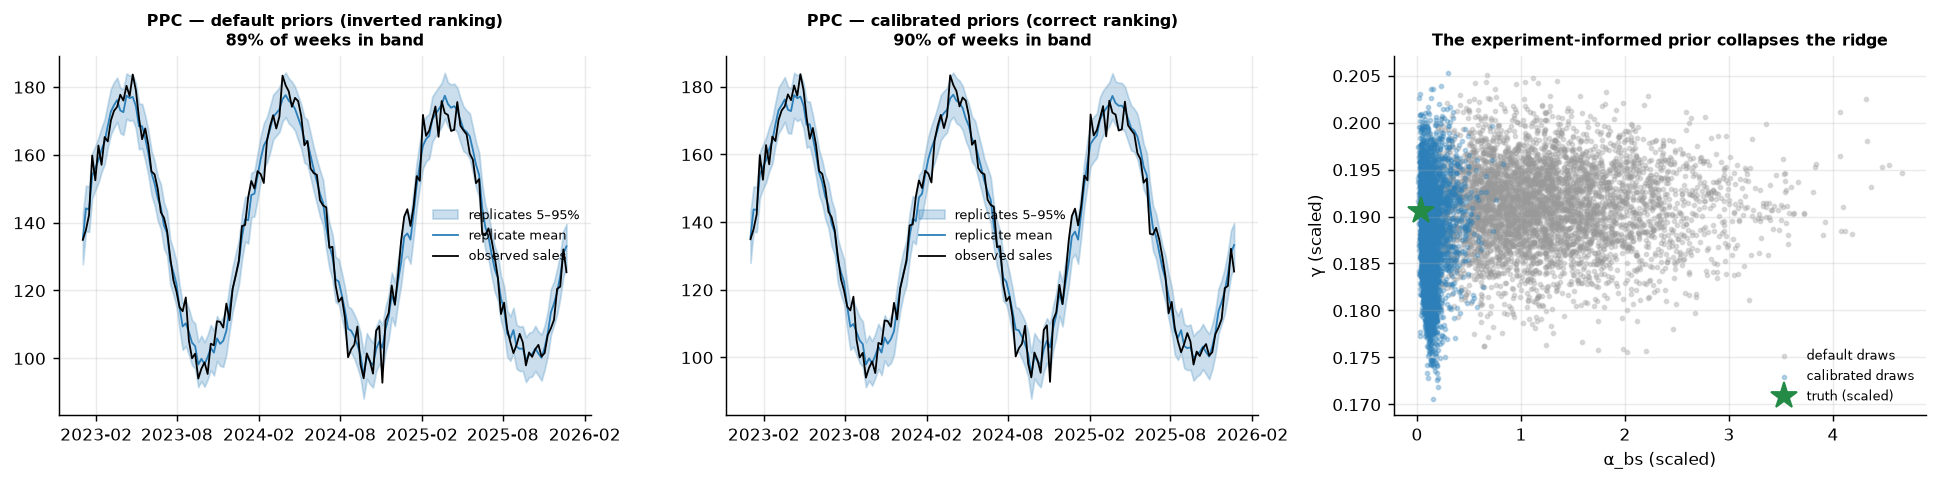

In [10]:
def ppc_band(m, seed=SEED):
    ds = m.sample_posterior_predictive(X, extend_idata=True, combined=True, original_scale=True,
                                       random_seed=seed, progressbar=False)
    yr = ds["y"].values
    if ds["y"].dims[0] == "sample":            # normalise to (date, sample)
        yr = yr.T
    lo, hi = np.quantile(yr, [0.05, 0.95], axis=1)
    cov = float(np.mean((y.values >= lo) & (y.values <= hi)))
    rmse = float(np.sqrt(np.mean((yr.mean(axis=1) - y.values) ** 2)))
    return yr.mean(axis=1), lo, hi, cov, rmse

covs, rmses = {}, {}
fig, ax = plt.subplots(1, 3, figsize=(15.0, 3.8))
for a, (key, ttl, m) in zip(ax[:2], [("default", "default priors (inverted ranking)", mmm_default),
                                     ("calibrated", "calibrated priors (correct ranking)", mmm)]):
    mu_r, lo, hi, cov, rmse = ppc_band(m)
    covs[key], rmses[key] = cov, rmse
    a.fill_between(df["date_week"], lo, hi, color=plots.BLUE, alpha=0.25, label="replicates 5–95%")
    a.plot(df["date_week"], mu_r, color=plots.BLUE, lw=1.0, label="replicate mean")
    a.plot(df["date_week"], y.values, color="k", lw=1.0, label="observed sales")
    a.set_title(f"PPC — {ttl}\n{cov:.0%} of weeks in band", fontsize=9)
    a.legend(frameon=False, fontsize=7)
# third panel: what the calibrated prior did to the ridge of the previous section
y_max = float(np.abs(y).max())
for idt, col, lab in [(idata_def, plots.GREY, "default draws"), (idata_cal, plots.BLUE, "calibrated draws")]:
    ax[2].scatter(idt.posterior["saturation_alpha"].sel(channel="brand_search").values.ravel(),
                  idt.posterior["gamma_control"].isel(control=0).values.ravel(),
                  s=5, alpha=0.3, color=col, label=lab)
ax[2].plot([8 / y_max], [35 / y_max], "*", color=plots.GREEN, ms=15, label="truth (scaled)")
ax[2].set_xlabel("α_bs (scaled)"); ax[2].set_ylabel("γ (scaled)")
ax[2].set_title("The experiment-informed prior collapses the ridge", fontsize=9)
ax[2].legend(frameon=False, fontsize=7)
import matplotlib.dates as mdates
for a in ax[:2]:
    a.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    a.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.tight_layout()
print(f"share of observed weeks inside the 5–95% replicate band — default {covs['default']:.0%} · "
      f"calibrated {covs['calibrated']:.0%}   (nominal ≈ 90%)")
print(f"replicate-mean RMSE (€/week)                              — default {rmses['default']:.1f} · "
      f"calibrated {rmses['calibrated']:.1f}   (DGP noise σ = 4)")
print("Two decompositions that disagree by an order of magnitude on brand_search reproduce the observed")
print("sales series near-identically — the likelihood cannot tell them apart. The ridge is where they hide.")

**Read-out.** The two left panels are, for practical purposes, the same picture: near-identical
bands, coverage and RMSE (printed above) — yet the left model credits brand_search with tens of
times its true contribution. This is the precise sense in which the notebook's failure is
**identification, not fit**: the generator uses the MMM's own functional form (Step 2's
"well-specified" remark), so both fits sit near the same likelihood value, and no amount of
posterior-predictive checking can distinguish the inverted decomposition from the correct one. Keep
running PPCs — a model that *cannot* reproduce the series is disqualified before you read anything
off it — but treat them as **necessary, never sufficient** for a causal claim. *Right panel*: what
the experiment-informed prior actually did. The default posterior (grey) spreads along the ridge;
the calibrated posterior (blue) is pinned at the low-ceiling end, beside the truth. The prior did
not overrule the data — it **selected among answers the data could not rank**.

brand_search credit — naive 6,401 | OLS+season 222 | MMM default 36,007 | MMM calibrated 2,262 | true 518
calibrated ROAS — TV 2.08× [90% 0.34,8.67]  ·  brand_search 0.60× [90% 0.11,2.28]
TRUE ROAS       — TV 0.85× · brand_search 0.14×  (both below 1×: the MMM recovers the ranking but overstates levels)


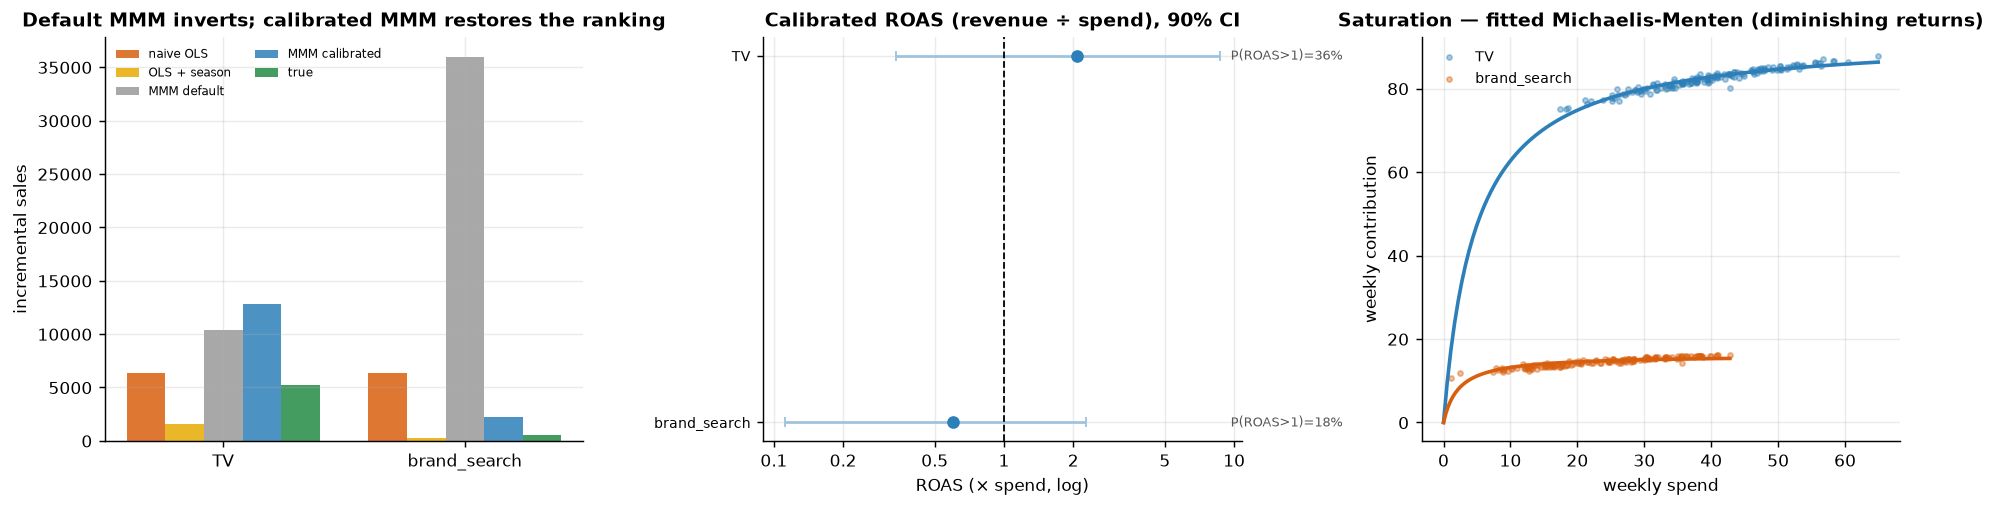

In [11]:
def credit(cols):
    Xn = np.column_stack([np.ones(len(df))] + [df[c].values for c in cols])
    b, *_ = np.linalg.lstsq(Xn, df["sales"].values, rcond=None)
    c = dict(zip(cols, b[1:])); return c["tv"]*df["tv"].sum(), c["brand_search"]*df["brand_search"].sum()
naive_tv, naive_bs = credit(["tv","brand_search"])
adj_tv, adj_bs = credit(["tv","brand_search","seasonality"])
spend_tv, spend_bs = df["tv"].sum(), df["brand_search"].sum()
roi_tv, roi_bs = tv_post/spend_tv, bs_post/spend_bs      # ROAS = revenue ÷ spend (calibrated MMM drives the decision)

fig, ax = plt.subplots(1, 3, figsize=(14.8, 4))
# (1) confounding correction — five estimators, GREY = the failure-mode default MMM
labels = ["TV","brand_search"]; x = np.arange(2); w = 0.16
series = [("naive OLS", [naive_tv,naive_bs], plots.ORANGE),
          ("OLS + season", [adj_tv,adj_bs], plots.GOLD),
          ("MMM default", [tv_def.mean(),bs_def.mean()], plots.GREY),
          ("MMM calibrated", [tv_post.mean(),bs_post.mean()], plots.BLUE),
          ("true", [true_tv,true_bs], plots.GREEN)]
for i,(lab,vals,col) in enumerate(series):
    ax[0].bar(x + (i-2)*w, vals, w, color=col, alpha=0.85, label=lab)
ax[0].set_xticks(x); ax[0].set_xticklabels(labels); ax[0].legend(frameon=False, fontsize=6.5, ncol=2)
ax[0].set_ylabel("incremental sales"); ax[0].set_title("Default MMM inverts; calibrated MMM restores the ranking")
# (2) ROI forest (calibrated MMM)
plots.forest_plot(ax[1], ["TV","brand_search"], [roi_tv.mean(),roi_bs.mean()],
    [np.quantile(roi_tv,.05),np.quantile(roi_bs,.05)], [np.quantile(roi_tv,.95),np.quantile(roi_bs,.95)],
    ref=1.0, title="Calibrated ROAS (revenue ÷ spend), 90% CI", xlabel="ROAS (× spend, log)",
    logx=True, annot=[f"P(ROAS>1)={(roi_tv>1).mean():.0%}", f"P(ROAS>1)={(roi_bs>1).mean():.0%}"])
import matplotlib.ticker as mtick
ax[1].xaxis.set_major_locator(mtick.LogLocator(base=10, subs=(1.0, 2.0, 5.0)))  # readable log ticks
ax[1].xaxis.set_major_formatter(mtick.FormatStrFormatter("%g"))
ax[1].xaxis.set_minor_locator(mtick.NullLocator())
# (3) saturation: weekly contribution vs weekly spend (calibrated MMM)
cw = mmm.compute_channel_contribution_original_scale().mean(dim=["chain","draw"])
ax[2].scatter(df["tv"], cw.sel(channel="tv").values, s=8, alpha=0.4, color=plots.BLUE, label="TV")
ax[2].scatter(df["brand_search"], cw.sel(channel="brand_search").values, s=8, alpha=0.4, color=plots.ORANGE, label="brand_search")
# overlay the fitted Michaelis-Menten saturation curve a*x/(b+x) per channel (not just the point cloud)
from scipy.optimize import curve_fit
def _mm(x, a, b): return a * x / (b + x)
for _chan, _col in [("tv", plots.BLUE), ("brand_search", plots.ORANGE)]:
    _xs = df[_chan].values; _ys = cw.sel(channel=_chan).values
    try:
        (_a, _b), _ = curve_fit(_mm, _xs, _ys, p0=[max(_ys.max(), 1.0), np.median(_xs) + 1e-9],
                                bounds=(0, np.inf), maxfev=20000)
        _gx = np.linspace(0, _xs.max(), 120)
        ax[2].plot(_gx, _mm(_gx, _a, _b), color=_col, lw=2)
    except Exception:
        pass
ax[2].set_xlabel("weekly spend"); ax[2].set_ylabel("weekly contribution"); ax[2].set_title("Saturation — fitted Michaelis-Menten (diminishing returns)"); ax[2].legend(frameon=False, fontsize=8)
fig.tight_layout()
print(f"brand_search credit — naive {naive_bs:,.0f} | OLS+season {adj_bs:,.0f} | MMM default {bs_def.mean():,.0f} | MMM calibrated {bs_post.mean():,.0f} | true {true_bs:,.0f}")
print(f"calibrated ROAS — TV {roi_tv.mean():.2f}× [90% {np.quantile(roi_tv,.05):.2f},{np.quantile(roi_tv,.95):.2f}]  ·  "
      f"brand_search {roi_bs.mean():.2f}× [90% {np.quantile(roi_bs,.05):.2f},{np.quantile(roi_bs,.95):.2f}]")
tr_tv, tr_bs = true_tv/spend_tv, true_bs/spend_bs
print(f"TRUE ROAS       — TV {tr_tv:.2f}× · brand_search {tr_bs:.2f}×  (both below 1×: the MMM recovers the ranking but overstates levels)")

**How to read this.** *Left* tells the whole story in one panel. **Naive OLS** (orange) over-credits
brand_search; **OLS + season** (gold) collapses that credit toward the small truth — the confounding
correction, working. Then the two MMMs: the **default** causal MMM (grey, the failure mode) *inverts* the
ranking, crediting brand_search far above TV — the seasonal-demand-stealing trap — while the **calibrated**
MMM (blue) restores TV above brand_search, landing beside the **true** bars (green). *Middle* — the
decision-relevant **calibrated ROAS**: TV's mean clears break-even but its 90% interval is wide and dips
below 1×, while brand_search's mean sits **below break-even**. So TV is the better channel, but its
above-break-even verdict is itself uncertain. And the ranking is only *probably* right: draw-by-draw, TV's
ROAS beats brand_search's about **78%** of the time in the committed FULL run (the `P(TV ROAS > brand_search ROAS)` computed in Step 6) —
more likely than not, but **short of the 0.8 bar** we'd want before moving real budget. *Right* — the
**saturation curves**: contribution flattens as spend rises (diminishing returns), so the *next* euro into a
channel is worth its curve's *slope*, not its average. The honest caveat (Step 7): even the calibrated ROAS
*levels* are approximate — anchor them with the same kind of geo experiment that supplied the prior.

### View 5 — grade the parameters, not just the contributions

Step 2 planted $\lambda = (0.4,\, 0.2)$, $\alpha = (60,\, 8)$, $\kappa = (50,\, 40)$, a baseline of
100 and a season coefficient of 35 — and the MMM estimates those same quantities, so we can grade
them directly (the cookbook's validation-first premise). One bookkeeping step first: the fitted
parameters live in max-abs-scaled units behind a *normalized* adstock, so we map each posterior
draw back to original units before comparing — the ceiling as
$\hat\alpha_c = \alpha^{(s)}_c \cdot \max_t(\text{sales}_t)$, the half-saturation as
$\hat\kappa_c = \kappa^{(s)}_c \cdot \max_t(x_{c,t}) \cdot S(\hat\lambda_c)$ where
$S(\lambda) = \sum_{\ell=0}^{7} \lambda^{\ell}$ is the adstock normalizer, and the decay
$\lambda_c$ compares as-is (it is scale-free). The question the table answers is not "are the
numbers perfect?" (they will not be — Step 4's caution about levels applies to parameters too) but
**where the error concentrates**.

In [12]:
y_max = float(np.abs(y).max())
TRUTH = {"tv": {"adstock decay": 0.40, "ceiling (€/wk)": 60.0, "half-sat (€)": 50.0},
         "brand_search": {"adstock decay": 0.20, "ceiling (€/wk)": 8.0, "half-sat (€)": 40.0}}

def implied_params(idt, ch):
    lam = idt.posterior["adstock_alpha"].sel(channel=ch).values.ravel()
    S = (1 - lam ** 8) / (1 - lam)                                   # adstock normalizer, l_max = 8
    return {"adstock decay": lam,
            "ceiling (€/wk)": idt.posterior["saturation_alpha"].sel(channel=ch).values.ravel() * y_max,
            "half-sat (€)": idt.posterior["saturation_lam"].sel(channel=ch).values.ravel()
                            * float(np.abs(df[ch]).max()) * S}

def _fmt(d):
    return f"{d.mean():.3g} [{np.quantile(d, .05):.3g}, {np.quantile(d, .95):.3g}]"

rows = []
for ch in ["tv", "brand_search"]:
    pdft, pcal = implied_params(idata_def, ch), implied_params(idata_cal, ch)
    for par in TRUTH[ch]:
        rows.append({"channel": ch, "parameter": par, "true": TRUTH[ch][par],
                     "default": _fmt(pdft[par]), "calibrated": _fmt(pcal[par])})
for nm, tru, pick in [("baseline (€/wk)", 100.0, lambda idt: idt.posterior["intercept"].values.ravel() * y_max),
                      ("season (€/wk)", 35.0,
                       lambda idt: idt.posterior["gamma_control"].isel(control=0).values.ravel() * y_max)]:
    rows.append({"channel": "—", "parameter": nm, "true": tru,
                 "default": _fmt(pick(idata_def)), "calibrated": _fmt(pick(idata_cal))})
print("Parameter recovery per fit — cells show posterior mean [90% CI];")
print("season coeff is EUR/wk per unit s_t.\n")
print(pd.DataFrame(rows).to_string(index=False))

ceil_d = implied_params(idata_def, "brand_search")["ceiling (€/wk)"].mean()
ceil_c = implied_params(idata_cal, "brand_search")["ceiling (€/wk)"].mean()
print(f"\nWhere the error concentrates: brand_search's fitted ceiling is ~{ceil_d / 8:.0f}×")
print(f"its true value under default priors, and ~{ceil_c / 8:.0f}× under the calibrated")
print("prior — the calibration acts on exactly the one parameter the data cannot")
print("pin down. TV's curve parameters stay loosely identified in BOTH fits (read")
print("the CIs above) — which is why Step 6 trusts the ranking, never the levels.")

Parameter recovery per fit — cells show posterior mean [90% CI];
season coeff is EUR/wk per unit s_t.

     channel       parameter  true               default            calibrated
          tv   adstock decay   0.4 0.234 [0.0473, 0.416] 0.223 [0.0416, 0.411]
          tv  ceiling (€/wk)  60.0       103 [43.9, 294]       114 [42.6, 353]
          tv    half-sat (€)  50.0      92.4 [1.72, 232]      81.3 [1.29, 222]
brand_search   adstock decay   0.2 0.351 [0.0645, 0.672] 0.336 [0.0388, 0.672]
brand_search  ceiling (€/wk)   8.0       232 [58.2, 478]        23.2 [7.9, 57]
brand_search    half-sat (€)  40.0   0.91 [0.0116, 1.37]      60.8 [0.39, 178]
           — baseline (€/wk) 100.0     -160 [-450, 50.8]        41 [-222, 119]
           —   season (€/wk)  35.0     35.1 [33.7, 36.4]         34.5 [33, 36]

Where the error concentrates: brand_search's fitted ceiling is ~29×
its true value under default priors, and ~3× under the calibrated
prior — the calibration acts on exactly the one par

**Read-out.** The table closes the loop on Step 4b's "not a thumb on the scale" claim. The default
fit's damage is *concentrated*: brand-search's ceiling — the parameter that can impersonate the
seasonal wave — inflates by an order of magnitude or more, and the level account is dragged along to offset
the inflated credit — read the baseline row, far from the planted 100. The calibrated prior moves **that one
number** back toward the truth and leaves every other parameter to the data — surgical, because the
experiment spoke to exactly the quantity the likelihood is silent about. Note also what calibration
does *not* fix: TV's ceiling and half-saturation remain wide and level-shifted in both fits.
Rankings, not levels — the caution of Step 4 holds at the parameter level too.

### View 6 — "didn't you just choose the prior that gives the answer you wanted?"

The skeptic's question, and it deserves a computed answer rather than a shrug. We refit the MMM
across a grid of prior means for brand-search's saturation ceiling — from half our calibrated value
up to the library default — keeping the same Gamma shape family throughout
($\mu_{bs} \in \{0.15, 0.3, 0.6, 1.0, 2.0\}$ in scaled units, $\sigma = \mu/2$). The 0.3 and 2.0
grid points *are* the two headline fits, reused rather than refit; the three new fits run at
**ranking-grade sampler settings** (short chains — stable posterior means and ranking
probabilities, not interval-grade diagnostics, exactly like notebook 01's stability sweep), so this
cell stays cheap in both FAST and FULL profiles. Two curves to read: each channel's estimated
contribution as the prior loosens, and $P(\text{contrib}_{tv} > \text{contrib}_{bs})$ against the
0.5 line (ranking flips) and the 0.8 action bar.

Output()

Output()

Output()

Ranking verdict across the sweep: correct (P > 0.5) for μ_bs ≤ 0.3; flipped by μ_bs = 0.6.
The geo experiment would have to be wrong by ~2× before the conclusion moved.
(Sweep fits are ranking-grade short chains: read the means and the flip point, not intervals.)


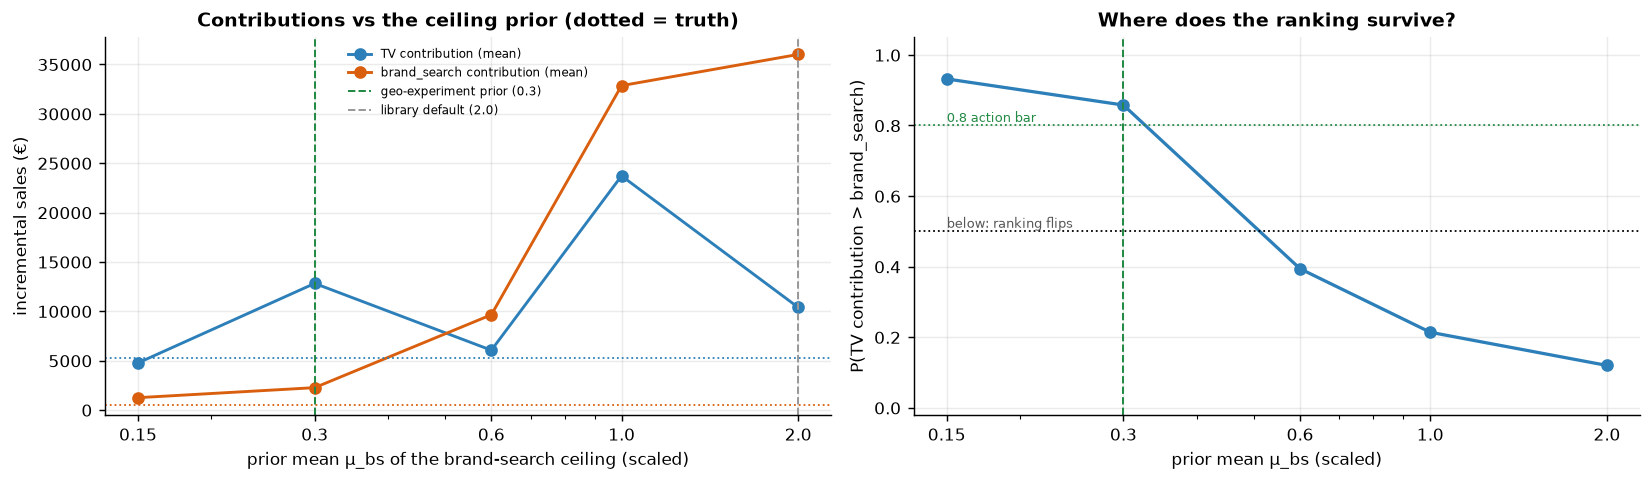

In [13]:
# Three refits would each spew a page of sampler chatter; silence the pymc logger for this cell
# (CRITICAL+1 because SamplerWarnings log at ERROR level). The convergence question for these
# ranking-grade fits is handled by design: we read only means and ranking probabilities.
import logging, pymc
logging.getLogger("pymc").setLevel(logging.CRITICAL + 1)

MUS = [0.15, 0.3, 0.6, 1.0, 2.0]
sweep = {0.3: (tv_post, bs_post),     # reuse fit (b): Gamma(mu=0.3, sigma=0.15) on brand_search
         2.0: (tv_def, bs_def)}       # reuse fit (a): the library default Gamma(mu=2, sigma=1)
for mu_bs in MUS:
    if mu_bs in sweep:
        continue
    mcs = dict(mmm_default.default_model_config)
    mcs["saturation_alpha"] = Prior("Gamma", mu=[2.0, mu_bs], sigma=[1.0, mu_bs / 2], dims="channel")
    ms = make_mmm(model_config=mcs)
    ms.fit(X, y, random_seed=SEED, progressbar=False, target_accept=0.9, **SWEEP_DRAWS)
    cs = ms.compute_channel_contribution_original_scale().sum(dim="date")
    sweep[mu_bs] = (cs.sel(channel="tv").values.ravel(), cs.sel(channel="brand_search").values.ravel())

mus = np.array(MUS)
tv_sw = np.array([sweep[m][0].mean() for m in MUS])
bs_sw = np.array([sweep[m][1].mean() for m in MUS])
p_rank = np.array([(sweep[m][0] > sweep[m][1]).mean() for m in MUS])

fig, ax = plt.subplots(1, 2, figsize=(12.8, 3.8))
ax[0].plot(mus, tv_sw, "o-", color=plots.BLUE, lw=1.6, label="TV contribution (mean)")
ax[0].plot(mus, bs_sw, "o-", color=plots.ORANGE, lw=1.6, label="brand_search contribution (mean)")
ax[0].axhline(true_tv, color=plots.BLUE, ls=":", lw=1); ax[0].axhline(true_bs, color=plots.ORANGE, ls=":", lw=1)
ax[0].axvline(0.3, color=plots.GREEN, ls="--", lw=1.1, label="geo-experiment prior (0.3)")
ax[0].axvline(2.0, color=plots.GREY, ls="--", lw=1.1, label="library default (2.0)")
ax[0].set_xscale("log"); ax[0].set_xticks(mus); ax[0].set_xticklabels([str(m) for m in MUS])
ax[0].set_xlabel("prior mean μ_bs of the brand-search ceiling (scaled)"); ax[0].set_ylabel("incremental sales (€)")
ax[0].set_title("Contributions vs the ceiling prior (dotted = truth)"); ax[0].legend(frameon=False, fontsize=6.5)
ax[1].plot(mus, p_rank, "o-", color=plots.BLUE, lw=1.8)
ax[1].axhline(0.5, color="k", ls=":", lw=1); ax[1].axhline(0.8, color=plots.GREEN, ls=":", lw=1)
ax[1].text(mus[0], 0.51, "below: ranking flips", fontsize=7, color="#555555")
ax[1].text(mus[0], 0.81, "0.8 action bar", fontsize=7, color=plots.GREEN)
ax[1].axvline(0.3, color=plots.GREEN, ls="--", lw=1.1)
ax[1].set_xscale("log"); ax[1].set_xticks(mus); ax[1].set_xticklabels([str(m) for m in MUS])
ax[1].set_ylim(-0.02, 1.05); ax[1].set_xlabel("prior mean μ_bs (scaled)")
ax[1].set_ylabel("P(TV contribution > brand_search)")
ax[1].set_title("Where does the ranking survive?")
for a in ax:
    a.xaxis.set_minor_formatter(plt.NullFormatter())
fig.tight_layout()

mus_ok = mus[p_rank > 0.5]; mus_flip = mus[p_rank <= 0.5]
if len(mus_ok) and len(mus_flip):
    print(f"Ranking verdict across the sweep: correct (P > 0.5) for μ_bs ≤ {mus_ok.max():g}; flipped by "
          f"μ_bs = {mus_flip.min():g}.")
    print(f"The geo experiment would have to be wrong by ~{mus_flip.min() / 0.3:.0f}× before the conclusion moved.")
elif len(mus_ok) == len(mus):
    print("Ranking verdict: correct at every grid point in this run — at these sampler settings even the")
    print("default prior did not flip it (the FULL-strength default fit above did; short chains wobble).")
else:
    print("Ranking verdict: flipped at every grid point in this run — re-run at FULL settings before reading.")
print("(Sweep fits are ranking-grade short chains: read the means and the flip point, not intervals.)")

**Read-out.** The conclusion is not an artifact of one hand-set prior. Across the
experiment-plausible range of prior means the calibrated ranking — TV above brand_search — holds,
and it only gives way as the prior mean approaches the library default, i.e. as we progressively
throw the experiment's information away (the printed line locates the flip for this run). The left
panel is the honest dial: loosening the prior slides brand-search's contribution smoothly from near
its dotted truth line back up toward the ridge's answer, with the data pushing back only weakly
anywhere along the way. That is what "the experiment carries the identification" looks like — and
it also quantifies robustness: a real geo test would have to be wrong by *about twofold* (roughly double), not a few
percent, before this budget decision changed direction.

## 6 · Decide, in euros — should we reallocate budget yet?

Budget chases **incremental return**, not last-click credit. One naming point first: what the MMM gives us is
**ROAS** — incremental *revenue* per euro of spend — not profit ROI. Break-even at 1× therefore assumes a
100% margin; at a realistic margin *m* the break-even ROAS is **1/m** (a 30% margin → 3.3×), which we show below.

Now that experiment-calibrated priors have made the *ranking* trustworthy, the point estimates put TV above
brand_search, so the *direction* of any reallocation is toward TV. But a direction is not a decision, and the
**absolute levels are still miscalibrated**. So we quantify three things: (1) the sales impact of shifting a
slice of budget — swept across shift sizes and made **saturation-aware**, so marginal ROAS falls as we pour
more into TV; (2) the posterior probability the move actually helps; and (3) the honest gap between the MMM's
ROAS and the *true* ROAS. That last check is the sobering one: it is why, even with the ranking fixed, the
absolute "is TV worth it?" question still belongs to a geo test (Anchor B, nb 07), not a still-approximate MMM.

**Average vs marginal, in symbols.** Two different euros-per-euro numbers get called "ROAS", and
budget moves must be priced with the second one:

$$
\mathrm{ROAS}_c \;=\; \frac{\sum_t f_c(a_{c,t})}{\sum_t x_{c,t}},
\qquad\qquad
\mathrm{mROAS}_c(\bar x) \;=\; \frac{\partial f_c}{\partial x}\bigg|_{x = \bar x}
\;=\; \frac{\alpha_c\, \kappa_c}{(\kappa_c + \bar x)^{2}},
$$

the **average** return on every euro already spent versus the **marginal** return on the *next*
euro at the current operating point $\bar x$ — and on a saturating curve the marginal is always
below the average (the curve's slope keeps falling). The optimal budget split is reached exactly
when marginal returns equalize across channels, $\mathrm{mROAS}_{tv} = \mathrm{mROAS}_{bs}$: that
equal-marginal-return condition is what the shift-size sweep below is finding numerically at its
peak (and what pymc-marketing's `BudgetOptimizer` solves directly in production).

TV ROAS — average 2.08× · marginal (the next euro, at today's spend) 0.23× — marginal is lower because of saturation (diminishing returns).



Shifting 15% of brand_search spend (€566) to TV → +€61 net sales (saturation-aware); the sweep peaks near 22%.
P(TV ROAS > brand_search ROAS) = 0.78 → lean toward TV, but test first

Ranking vs levels — the watertight part:
  TRUE ROAS: TV 0.85× · brand_search 0.14× (both BELOW 1×)  |  MMM says TV 2.08× · bs 0.60×
  The MMM recovers the RANKING (TV ≫ brand_search) but overstates LEVELS ~2.4× for TV.
  ROAS is revenue ÷ spend — it assumes 100% margin. At a realistic 30% margin the break-even is 1/0.30 ≈ 3.3×,
  which even TV's estimated 2.08× fails; and TV's TRUE ROAS 0.85× is below break-even at ANY margin.
  So: reallocate toward TV (the ranking is trustworthy), but 'is TV worth it in absolute €?' needs the geo
  experiment (nb 07) — this MMM's absolute levels are not calibrated enough to answer it.

Decision quantity WITH uncertainty — shift 15% (€566)
brand_search -> TV (per-draw, average-ROAS):
  Δsales = €836  [90% €-799, €4,618]  ·  P(Δ>0) = 0.78
  TRUE Δsales (from DGP true_con

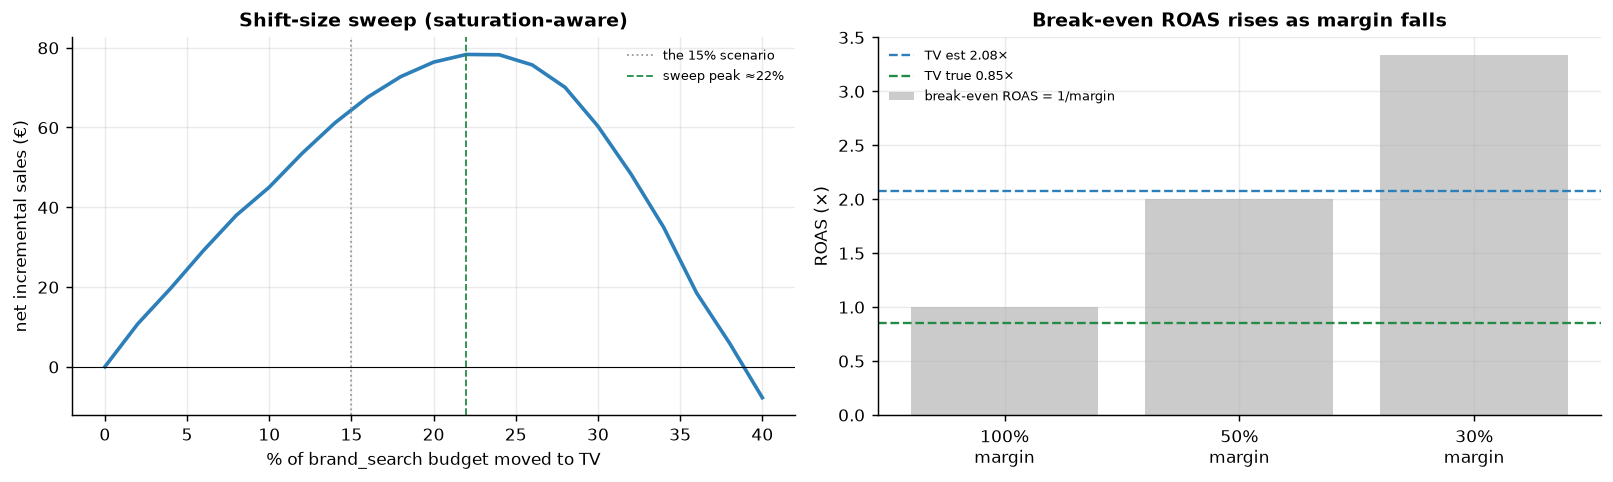

In [14]:
SHIFT = 0.15   # the single scenario — now shown inside a full shift-size sweep
n_wk = len(df)
# --- Saturation-aware marginal ROAS: fit the Michaelis-Menten response the MMM itself used to the
# fitted weekly (spend, contribution) points, so we can move budget ALONG the real saturating curve. ---
from scipy.optimize import curve_fit
def _mm(x, a, b): return a * x / (b + x)
def _contrib_fn(x, y):                       # -> (total_contribution(spend_array), mm_params or None)
    try:
        p, _ = curve_fit(_mm, x, y, p0=[max(y.sum()/len(y)*2, 1.0), max(np.median(x), 1.0)],
                         bounds=(0, np.inf), maxfev=20000)
        return (lambda s: _mm(s, *p).sum()), p
    except Exception:
        roas = y.sum() / x.sum()             # linear fallback: constant ROAS
        return (lambda s: float((roas * np.asarray(s)).sum())), None
cw_tv = cw.sel(channel="tv").values; cw_bs = cw.sel(channel="brand_search").values
tv_fn, p_tv = _contrib_fn(df["tv"].values, cw_tv)
bs_fn, p_bs = _contrib_fn(df["brand_search"].values, cw_bs)

# average vs marginal ROAS (per euro) at today's operating spend
avg_roas_tv = roi_tv.mean()
if p_tv is not None:
    a, b = p_tv; xbar = df["tv"].mean(); marg_roas_tv = a * b / (b + xbar) ** 2
else:
    marg_roas_tv = avg_roas_tv
print(f"TV ROAS — average {avg_roas_tv:.2f}× · marginal (the next euro, at today's spend) {marg_roas_tv:.2f}× "
      f"— marginal is lower because of saturation (diminishing returns).")

# --- Shift-size sweep: move x% of brand_search budget into TV, ALONG the fitted curves ---
shifts = np.linspace(0, 0.40, 21); tv0, bs0 = df["tv"].values, df["brand_search"].values
net_gain = np.array([tv_fn(tv0 + s*spend_bs/n_wk) - tv_fn(tv0)
                     - (bs_fn(bs0) - bs_fn(np.clip(bs0 - s*spend_bs/n_wk, 0, None))) for s in shifts])
best = int(np.nanargmax(net_gain)); best_shift = shifts[best]

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.8))
ax[0].plot(shifts*100, net_gain, color=plots.BLUE, lw=2)
ax[0].axvline(SHIFT*100, color=plots.GREY, ls=":", lw=1, label=f"the {SHIFT:.0%} scenario")
ax[0].axvline(best_shift*100, color=plots.GREEN, ls="--", lw=1, label=f"sweep peak ≈{best_shift:.0%}")
ax[0].axhline(0, color="k", lw=0.6); ax[0].set_xlabel("% of brand_search budget moved to TV")
ax[0].set_ylabel("net incremental sales (€)"); ax[0].set_title("Shift-size sweep (saturation-aware)")
ax[0].legend(frameon=False, fontsize=7)
margins = [1.00, 0.50, 0.30]
ax[1].bar([f"{int(m*100)}%\nmargin" for m in margins], [1/m for m in margins], color=plots.GREY, alpha=0.5, label="break-even ROAS = 1/margin")
ax[1].axhline(roi_tv.mean(), color=plots.BLUE, ls="--", lw=1.3, label=f"TV est {roi_tv.mean():.2f}×")
ax[1].axhline(true_tv/spend_tv, color=plots.GREEN, ls="--", lw=1.3, label=f"TV true {true_tv/spend_tv:.2f}×")
ax[1].set_ylabel("ROAS (×)"); ax[1].set_title("Break-even ROAS rises as margin falls"); ax[1].legend(frameon=False, fontsize=7)
fig.tight_layout()

p_gain = (roi_tv > roi_bs).mean()
delta_sat = float(net_gain[np.argmin(np.abs(shifts - SHIFT))])
tr_tv, tr_bs = true_tv/spend_tv, true_bs/spend_bs
print(f"\nShifting {SHIFT:.0%} of brand_search spend (€{SHIFT*spend_bs:,.0f}) to TV → +€{delta_sat:,.0f} net sales "
      f"(saturation-aware); the sweep peaks near {best_shift:.0%}.")
print(f"P(TV ROAS > brand_search ROAS) = {p_gain:.2f} → " + ("reallocate toward TV" if p_gain > 0.8 else "lean toward TV, but test first"))
print(f"\nRanking vs levels — the watertight part:")
print(f"  TRUE ROAS: TV {tr_tv:.2f}× · brand_search {tr_bs:.2f}× (both BELOW 1×)  |  MMM says TV {roi_tv.mean():.2f}× · bs {roi_bs.mean():.2f}×")
print(f"  The MMM recovers the RANKING (TV ≫ brand_search) but overstates LEVELS ~{roi_tv.mean()/tr_tv:.1f}× for TV.")
print(f"  ROAS is revenue ÷ spend — it assumes 100% margin. At a realistic 30% margin the break-even is 1/0.30 ≈ {1/0.30:.1f}×,")
print(f"  which even TV's estimated {roi_tv.mean():.2f}× fails; and TV's TRUE ROAS {tr_tv:.2f}× is below break-even at ANY margin.")
print(f"  So: reallocate toward TV (the ranking is trustworthy), but 'is TV worth it in absolute €?' needs the geo")
print(f"  experiment (nb 07) — this MMM's absolute levels are not calibrated enough to answer it.")

# --- Decision quantity WITH uncertainty + recover-the-truth check (per posterior draw, not just the mean) ---
# The net_gain sweep above is saturation-aware but uses only MEAN weekly contributions. Carry the same 15%
# reallocation through EVERY posterior draw via each draw's channel ROAS (roi_tv/roi_bs, from tv_post/bs_post)
# — a first-order (average-ROAS) reallocation — to put an interval and P(Δ>0) on the decision quantity, then
# check it against the DGP truth already loaded in true_contrib (true_tv/true_bs).
A = SHIFT * spend_bs                                    # euros moved brand_search -> TV
delta_draws = A * (roi_tv - roi_bs)                     # per-draw Δsales (average-ROAS reallocation)
d_lo, d_hi = np.quantile(delta_draws, [0.05, 0.95])
p_help = float((delta_draws > 0).mean())
true_delta = A * (tr_tv - tr_bs)                        # DGP truth: same shift priced at TRUE channel ROAS
print(f"\nDecision quantity WITH uncertainty — shift {SHIFT:.0%} (€{A:,.0f})")
print("brand_search -> TV (per-draw, average-ROAS):")
print(f"  Δsales = €{delta_draws.mean():,.0f}  [90% €{d_lo:,.0f}, €{d_hi:,.0f}]  ·  P(Δ>0) = {p_help:.2f}")
print(f"  TRUE Δsales (from DGP true_contrib) = €{true_delta:,.0f}  ->  direction check: "
      + ("MATCH (both favour TV)" if np.sign(delta_draws.mean()) == np.sign(true_delta) else "MISMATCH"))

# The two figures cell 32 weighs, for the SAME shift — printed side by side so the prose can point here.
print(f"\nTHE TWO Δsales FIGURES cell 32 weighs, same {SHIFT:.0%} shift:")
print(f"  - saturation-aware (walks both channels DOWN their fitted curves)   : €{delta_sat:,.0f}/week  <- the honest planning number")
print(f"  - average-ROAS     (ignores saturation, carries the uncertainty band): €{delta_draws.mean():,.0f}/week [90% €{d_lo:,.0f}, €{d_hi:,.0f}], P(Δ>0)={p_help:.2f}")

# --- Price the geo experiment itself (value of information). What would acting on the DEFAULT
# MMM have cost? Its inverted ranking (brand_search >> TV) implies the MIRROR action: move 15% of
# the TV budget INTO brand_search. Price both policies at the TRUE channel ROAS from the DGP.
A_bad = SHIFT * spend_tv                       # euros the default MMM would have moved tv -> brand_search
delta_bad = A_bad * (tr_bs - tr_tv)            # < 0 by the planted truth: value destroyed per window
swing = true_delta - delta_bad                 # what the experiment's information was worth, per window
print(f"\nPricing the experiment (the notebook's punchline, in euros): acting on")
print(f"the DEFAULT MMM means shifting {SHIFT:.0%} of TV spend (€{A_bad:,.0f}) into")
print(f"brand_search -> Δsales = €{delta_bad:,.0f} per planning window (value DESTROYED);")
print(f"acting on the CALIBRATED MMM adds €{true_delta:,.0f}. The swing, €{swing:,.0f}")
print(f"per window — recurring every window — is a FLOOR on what the geo experiment")
print(f"that calibrated the prior was worth (it prices only this one {SHIFT:.0%}")
print(f"decision, nothing else the calibration de-risks). If the test costs less")
print(f"than a few windows of that, it pays for itself.")

**Which Δsales number goes to the CFO?** The block just above prints **two Δsales figures for the same 15% shift**, and they differ by roughly an order of magnitude *on purpose*. The **saturation-aware** figure walks both channels *down* their fitted response curves — at TV's current operating point the marginal curve is already nearly flat, so the honest planning number is small (in the committed FULL run ≈ +€61/week; a FAST run prints an even smaller, noisier value that can dip slightly negative). The **average-ROAS** figure prices the same shift at each posterior draw's *average* ROAS — it ignores saturation entirely, so it lands far larger (≈ +€836/week in the FULL run, ~14× the saturation-aware figure), and is kept only because it carries the uncertainty band: its printed P(Δ>0) is the **ranking probability in euro clothing** — by construction Δ>0 exactly when TV's ROAS beats brand_search's. **Quote the saturation-aware figure to the CFO; use the average-ROAS band as the direction check it is.**

### Giving the planning number its band

One loose end, flagged honestly: the saturation-aware sweep above was built by re-fitting a
Michaelis–Menten curve to the **posterior-mean** weekly contributions with `scipy.curve_fit` — a
plug-in convenience that throws the posterior away, which is why the saturation-aware planning number above
printed with no interval while the cruder average-ROAS number carried one. A notebook that preaches
posteriors should not quietly switch to point estimates for its decision-critical figure. The fix
costs almost nothing: repeat the same curve fit on **each posterior draw** of the calibrated MMM's
weekly contributions, push every draw through the same budget shift, and the sweep inherits a
genuine 90% credible band.

Saturation-aware Δsales at the 15% shift: median €59 [90% €-13, €115] · P(Δ>0) = 0.90 (from 300 of 300 draws)
This is the CFO sentence completed: quote the saturation-aware median WITH its band, alongside the
ranking probability — the band separates conviction from hope.


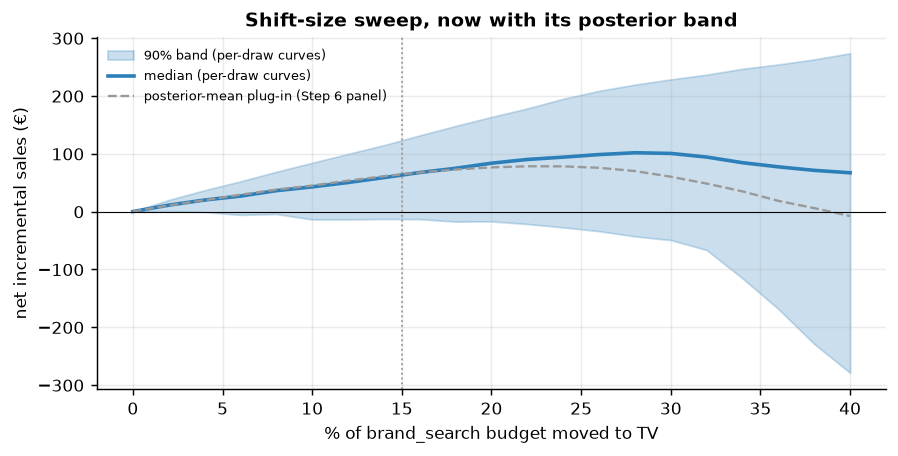

In [15]:
stk = mmm.compute_channel_contribution_original_scale().stack(sample=("chain", "draw"))
n_s = int(stk.sizes["sample"]); take = min(150 if FAST else 300, n_s)
sel = np.random.default_rng(SEED).choice(n_s, size=take, replace=False)
gain_draws = np.full((take, len(shifts)), np.nan)
for k, i in enumerate(sel):
    try:
        ptv, _ = curve_fit(_mm, tv0, stk.sel(channel="tv").isel(sample=int(i)).values,
                           p0=[max(cw_tv.max(), 1.0), max(np.median(tv0), 1.0)], bounds=(0, np.inf), maxfev=8000)
        pbs, _ = curve_fit(_mm, bs0, stk.sel(channel="brand_search").isel(sample=int(i)).values,
                           p0=[max(cw_bs.max(), 1.0), max(np.median(bs0), 1.0)], bounds=(0, np.inf), maxfev=8000)
    except Exception:
        continue                                   # a failed draw stays NaN and drops out of the quantiles
    for j, s in enumerate(shifts):
        gain_draws[k, j] = (_mm(tv0 + s * spend_bs / n_wk, *ptv).sum() - _mm(tv0, *ptv).sum()
                            - (_mm(bs0, *pbs).sum() - _mm(np.clip(bs0 - s * spend_bs / n_wk, 0, None), *pbs).sum()))

lo_g, med_g, hi_g = np.nanquantile(gain_draws, [0.05, 0.5, 0.95], axis=0)
fig, ax = plt.subplots(figsize=(7.0, 3.6))
ax.fill_between(shifts * 100, lo_g, hi_g, color=plots.BLUE, alpha=0.25, label="90% band (per-draw curves)")
ax.plot(shifts * 100, med_g, color=plots.BLUE, lw=2, label="median (per-draw curves)")
ax.plot(shifts * 100, net_gain, color=plots.GREY, lw=1.3, ls="--", label="posterior-mean plug-in (Step 6 panel)")
ax.axhline(0, color="k", lw=0.6); ax.axvline(SHIFT * 100, color=plots.GREY, ls=":", lw=1)
ax.set_xlabel("% of brand_search budget moved to TV"); ax.set_ylabel("net incremental sales (€)")
ax.set_title("Shift-size sweep, now with its posterior band"); ax.legend(frameon=False, fontsize=7)
fig.tight_layout()
j15 = int(np.argmin(np.abs(shifts - SHIFT)))
d15 = gain_draws[:, j15]; d15 = d15[~np.isnan(d15)]
p15 = float((d15 > 0).mean())
print(f"Saturation-aware Δsales at the {SHIFT:.0%} shift: median €{np.median(d15):,.0f} "
      f"[90% €{np.quantile(d15, .05):,.0f}, €{np.quantile(d15, .95):,.0f}] · P(Δ>0) = {p15:.2f} "
      f"(from {len(d15)} of {take} draws)")
print("This is the CFO sentence completed: quote the saturation-aware median WITH its band, alongside the")
print("ranking probability — the band separates conviction from hope"
      + (". NOTE (FAST run): short ranking-grade chains make this sizing readout noisy — the ranking is"
         "\nstable across modes, but SIZE the move from a FULL run." if FAST else "."))

### The one-paragraph decision

> **Recommendation: act on the ranking, pilot the shift, and let a geo test set the levels.** The
> calibrated MMM's channel **ranking** — TV above brand_search — is the trustworthy part of this
> analysis: it is direction-checked against the planted truth, it survives the entire
> experiment-plausible prior range in View 6, and the posterior predictive check showed the
> competing default-prior reading buys no extra fit — the experiment, not the data, is what
> identified it. *How much* to move is where honesty bites: judge the printed
> $P(\text{TV beats brand\_search})$ against the 0.8 action bar (in the committed FULL run it lands
> just short, at ≈0.78 — hence "pilot", not "reallocate"), and size the pilot from the
> **saturation-aware sweep with its band**, never from average ROAS — in the FULL run that sweep
> peaks at a roughly one-fifth shift, while a FAST run's short chains are ranking-grade only and
> should not size anything. The absolute euro **levels** are explicitly not decision-grade: the MMM
> overstates contributions several-fold even after calibration, and the *true* TV ROAS sits below
> break-even at any margin, so "is TV worth it at all?" belongs to the geo experiment (nb 07) —
> whose per-window value the swing computation above already floors in euros, recurring every
> planning cycle. Act on the ranking; pilot the shift; let the experiment set the levels.

In [16]:
import json
decision = {
    "true_contribution_eur": {"tv": round(true_tv), "brand_search": round(true_bs)},
    "mmm_default": {"tv": round(float(tv_def.mean())), "brand_search": round(float(bs_def.mean())),
                    "ranking_correct": bool(tv_def.mean() > bs_def.mean()),
                    "convergence": est.convergence_report(idata_def)["summary"]},
    "mmm_calibrated": {"tv": round(float(tv_post.mean())), "brand_search": round(float(bs_post.mean())),
                       "ranking_correct": bool(tv_post.mean() > bs_post.mean()),
                       "convergence": est.convergence_report(idata_cal)["summary"]},
    "ppc_share_in_90pct_band": {"default": round(covs["default"], 2), "calibrated": round(covs["calibrated"], 2)},
    "p_rank_correct_calibrated": round(float(p_gain), 2), "action_bar": 0.8,
    "prior_sweep": {"grid_mu_bs": MUS, "p_tv_beats_bs": [round(float(p), 2) for p in p_rank],
                    "flips_at_mu": (float(mus_flip.min()) if len(mus_flip) else None)},
    "chosen_shift_of_bs_budget": SHIFT,
    "delta_sales_saturation_aware_eur": {"median": round(float(np.median(d15))),
                                         "lo90": round(float(np.quantile(d15, .05))),
                                         "hi90": round(float(np.quantile(d15, .95))),
                                         "p_positive": round(p15, 2)},
    "delta_sales_avg_roas_eur": {"mean": round(float(delta_draws.mean())),
                                 "lo90": round(float(d_lo)), "hi90": round(float(d_hi))},
    "true_delta_sales_eur": round(float(true_delta)),
    "experiment_value_floor_eur_per_window": round(float(swing)),
    "verdict": "pilot shift toward TV (ranking trustworthy); geo test for absolute levels",
}
print(json.dumps(decision, indent=2))

{
  "true_contribution_eur": {
    "tv": 5263,
    "brand_search": 518
  },
  "mmm_default": {
    "tv": 10390,
    "brand_search": 36007,
    "ranking_correct": false,
    "convergence": "max r-hat 1.010 - min ESS 381 - divergences 14"
  },
  "mmm_calibrated": {
    "tv": 12820,
    "brand_search": 2262,
    "ranking_correct": true,
    "convergence": "max r-hat 1.010 - min ESS 376 - divergences 0"
  },
  "ppc_share_in_90pct_band": {
    "default": 0.89,
    "calibrated": 0.9
  },
  "p_rank_correct_calibrated": 0.78,
  "action_bar": 0.8,
  "prior_sweep": {
    "grid_mu_bs": [
      0.15,
      0.3,
      0.6,
      1.0,
      2.0
    ],
    "p_tv_beats_bs": [
      0.93,
      0.86,
      0.39,
      0.21,
      0.12
    ],
    "flips_at_mu": 0.6
  },
  "chosen_shift_of_bs_budget": 0.15,
  "delta_sales_saturation_aware_eur": {
    "median": 59,
    "lo90": -13,
    "hi90": 115,
    "p_positive": 0.9
  },
  "delta_sales_avg_roas_eur": {
    "mean": 836,
    "lo90": -799,
    "hi90": 46

## 7 · Caveats

- **Absolute contributions need calibration.** Even the calibrated MMM runs a few times too high in absolute euros,
  because channel spend rides the seasonal wave the model can't fully net out from a short series. **Trust
  the ranking and the ROI verdict, not the absolute euros** — and note it took an experiment-informed prior
  to get even the *ranking* right. This is the single most important thing to say about any MMM.
- **A DAG is necessary but not sufficient.** The correct backdoor control (seasonality) did not stop a
  flexibly-saturated, collinear channel from re-absorbing the confounder. Structural assumptions still need
  experimental calibration to be trustworthy.
- **Adstock/saturation priors matter — a lot.** Carry-over (λ) and diminishing-returns (α, κ) are weakly
  identified from limited weekly data; here the saturation-ceiling prior *flipped the conclusion*. Use
  informative priors from experiments wherever you have them.
- **Correlated channels → wide, correlated ROI posteriors.** When spend moves with a confounder, the data
  can't fully separate them; the intervals will (honestly) show it.